In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc, copy
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio

In [2]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_noveto_20221031.fits'))
# cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/daily/lss_daily_y1_lrg_full_20221031.fits'))
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# GOODHARDLOC
mask = cat['GOODHARDLOC']==True
print('GOODHARDLOC   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as STARs
mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Require a minimum depth for the cat coadd
# min_depth = 800.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_daily_20221101.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()

# mask = cat['EBV']<0.1
# print(np.sum(mask)/len(mask))
# cat = cat[mask]
# print(len(cat))

print(len(cat))

5235371
FIBERSTATUS    2444313 2791058 0.46688439081012595
GOODHARDLOC    6279 2784779 0.002249684528232663
No data    0 2784779 0.0
LRG mask 2529655 255124 0.09161373308258931
Remove QSO targets 2504876 24779 0.009795406883547362
Remove objects classified as QSOs: 2473491 31385 0.012529562341608926
Remove objects classified as STARs: 2464858 8633 0.00349020877779624
65
Bad fibers 2441185 23673 0.00960420438013062
0.012791328801381296
2441185


In [4]:
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

# Use the coefficients from the LRG target selection paper
coeffs = [-0.0911, 3.34, 0.0228]  # Main+SV3

a0, a1, a2 = -1/coeffs[1], -coeffs[0]/coeffs[1], coeffs[2]
print(a0, a1, a2)

-0.29940119760479045 0.02727544910179641 0.0228


In [34]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['fail_prob'] = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)

min_count = 1

print('Predicted failure rate: {:.2f}%'.format(100*np.sum(cat['fail_prob'])/len(cat)))
print('Actual failure rate:    {:.2f}%'.format(100*np.sum(~cat['q'])/len(cat)))

Predicted failure rate: 1.22%
Actual failure rate:    1.28%


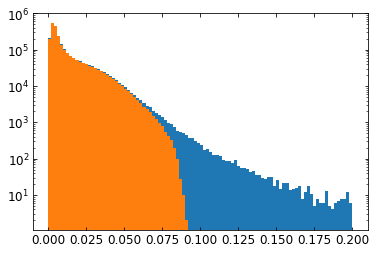

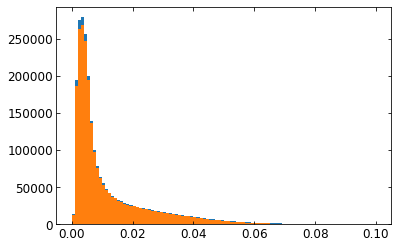

In [41]:
plt.hist(cat['fail_prob'], 100, log=True, range=(0, 0.2))
plt.hist(cat['fail_prob'][cat['EFFTIME_LRG']>800], 100, log=True, range=(0, 0.2))
plt.show()

plt.hist(cat['fail_prob'], 100, log=False, range=(0, 0.1))
plt.hist(cat['fail_prob'][cat['EFFTIME_LRG']>800], 100, log=False, range=(0, 0.1))
plt.show()

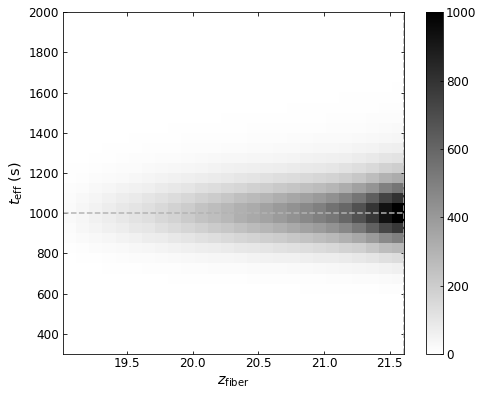

/tmp/ipykernel_50439/3308915709.py:23: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/tmp/ipykernel_50439/3308915709.py:25: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


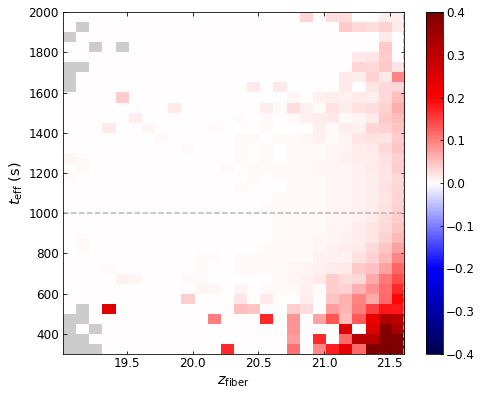

/tmp/ipykernel_50439/3308915709.py:46: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


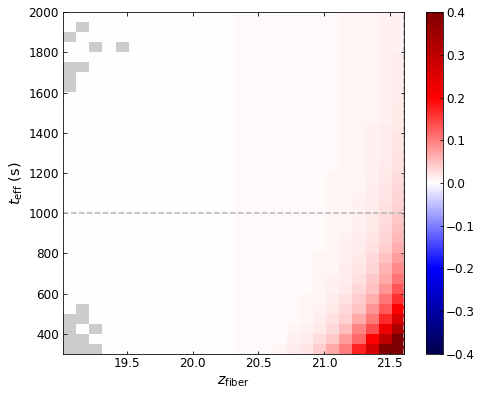

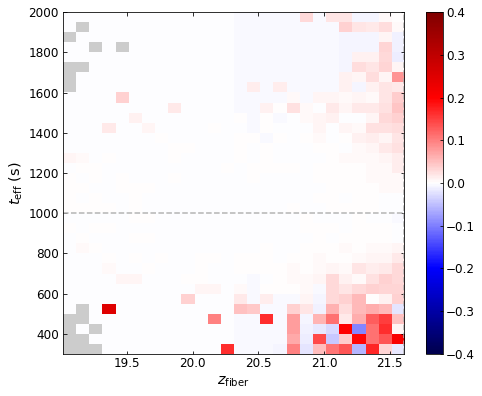

Adjust color stretch:


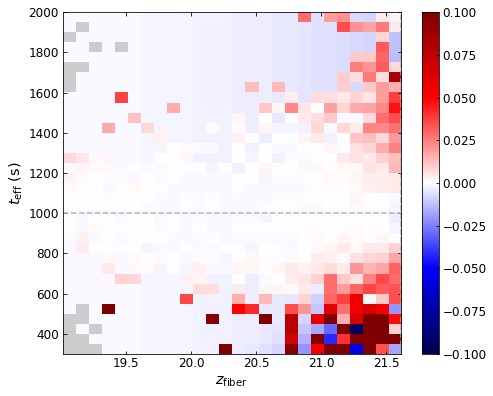

In [32]:
zfiber_bin_edges = np.linspace(18.01, 22.01, 41)
efftime_bin_edges = np.linspace(100, 2000, 39)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow((count_2d_all/count_2d_all.max()*1000).T, origin='lower', aspect='auto', cmap='gray_r',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(19.01, 21.61)
ax.set_ylim(ymin=300)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = (~cat['q']).copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d = count_2d_good/count_2d_all
success_2d[count_2d_all<=min_count] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=-0.4, vmax=0.4, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(19.01, 21.61)
ax.set_ylim(ymin=300)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

###############################################################################################

count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['fail_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=min_count] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=-0.4, vmax=0.4, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(19.01, 21.61)
ax.set_ylim(ymin=300)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow((success_2d-success_2d_predict).T, origin='lower', aspect='auto', vmin=-0.4, vmax=0.4, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(19.01, 21.61)
ax.set_ylim(ymin=300)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

print('Adjust color stretch:')
fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow((success_2d-success_2d_predict).T, origin='lower', aspect='auto', vmin=-0.1, vmax=0.1, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(19.01, 21.61)
ax.set_ylim(ymin=300)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

/tmp/ipykernel_50439/503858185.py:16: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/tmp/ipykernel_50439/503858185.py:18: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/tmp/ipykernel_50439/503858185.py:34: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


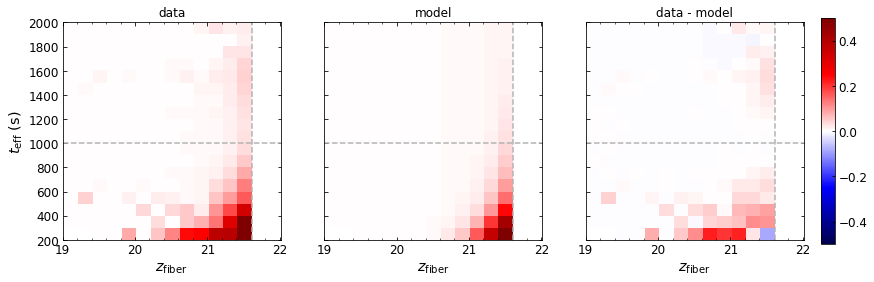

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
# current_cmap.set_bad(color='0.8')

###############################################################################################

ax = axes[0]

zfiber_bin_edges = np.linspace(18.01, 22.01, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = (~cat['q']).copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d = count_2d_good/count_2d_all
success_2d[count_2d_all<=min_count] = np.nan

cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
ax.set_title('data')
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[1]
count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['fail_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=min_count] = np.nan
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
ax.set_title('model')
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[2]
cax = ax.imshow((success_2d-success_2d_predict).T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
ax.set_title('data - model')
ax.xaxis.set_minor_locator(AutoMinorLocator())

fig.colorbar(cax, ax=axes, location='right', shrink=1.04, pad=0.02, aspect=17)
plt.show()

--------

In [42]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

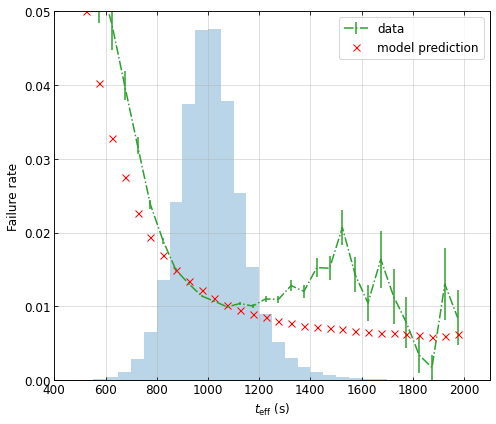

In [44]:
mask = np.full(len(cat), True)

area = len(cat)/600

bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~cat['q'][mask]), bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['EFFTIME_LRG'][mask], cat['fail_prob'][mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2', label='data')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', color='r', ms=7, label='model prediction')
# ax1.xlabel('EFFTIME_LRG')
ax1.set_xlabel('$t_\mathrm{eff}$ (s)')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[::-1], labels[::-1], loc='upper right')
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['EFFTIME_LRG'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
# ax2.set_ylabel('a.u.', color=ax2_color)
# ax2.tick_params(axis='y', labelcolor=ax2_color)
ax2.yaxis.set_visible(False)
ax1.set_zorder(1)
ax1.patch.set_visible(False)
ax1.axis([400, 2100, 0.00, 0.05])
plt.tight_layout()
plt.show()

/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


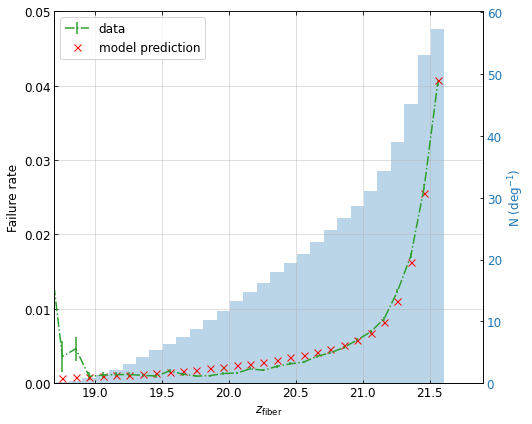

In [47]:
mask = (cat['EFFTIME_LRG']>800.) & (cat['EFFTIME_LRG']<1200.)

bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

# mask = mask & (cat['survey']=='main')
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['zfibermag'][mask], cat['fail_prob'][mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2', label='data')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', ms=7, color='r', label='model prediction')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[::-1], labels[::-1], loc='upper left')
ax1.axis([18.7, 21.9, 0.00, 0.05])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['zfibermag'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()

126.963104


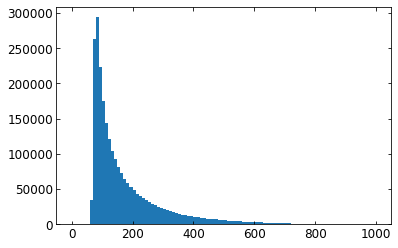

In [52]:
sn = cat['FIBERFLUX_Z_EC']*np.sqrt(cat['EFFTIME_LRG'])
print(np.median(sn))
plt.hist(sn, 100, range=(0, 1000));

/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/global/common/software/desi/perlmutter/desiconda/20220119-2.0.1/conda/lib/python3.9/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


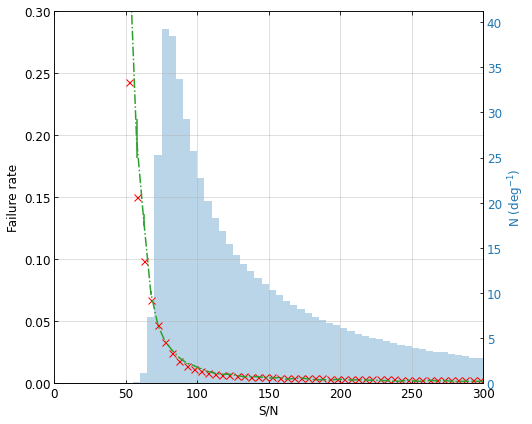

In [53]:
mask = (cat['EFFTIME_LRG']>200.)

bin_edges = np.linspace(25, 325, 61)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

# mask = mask & (cat['survey']=='main')
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(sn[mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(sn[mask], cat['fail_prob'][mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', ms=7, color='r')
ax1.set_xlabel('S/N')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper left')
# ax1.title('cat LRGs')
ax1.axis([0, 300, 0.00, 0.3])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(sn[mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()